In [1]:
import torch
import umap.umap_ as umap 
from feature_visualization import FeatureAnalyzer
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import numpy as np
import wandb



/Users/adityaiyer/Desktop/Projects/sae-monosemantic/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from pathlib import Path

expansion_factor = 4
model_dim = 768

project_root = Path(__file__).resolve().parents[2] if "__file__" in dir() else Path.cwd().resolve()
while project_root != project_root.parent and not (project_root / "pyproject.toml").exists():
    project_root = project_root.parent

model_weight_path = project_root / f'model_weights_{expansion_factor}x.pth'
HF_path = f'thedarkknight7/SAE_monosemanticity_features_{expansion_factor}x'
db_name = str(project_root / "hf_trial")
table_name = f"hf_{expansion_factor}x_full"

In [3]:
weights_dictionary = torch.load(model_weight_path, map_location = 'cpu')
print(list(weights_dictionary.keys()))

['W_enc', 'b_enc', 'W_dec', 'b_dec']


In [4]:
W_dec = weights_dictionary['W_dec']

In [5]:
feature_analyzer = FeatureAnalyzer(
        HF_dataset_path = HF_path,
        db_name = db_name,
        expansion_factor = expansion_factor
    )

In [6]:
dead_neurons_idxs = feature_analyzer.get_dead_features(table_name = table_name)["feature_id"].tolist()

In [7]:
embedding = umap.UMAP(n_components=3).fit_transform(W_dec.numpy())

In [8]:
dead_set = set(dead_neurons_idxs)
df = pd.DataFrame({
    'UMAP 1': embedding[:, 0],
    'UMAP 2': embedding[:, 1],
    'UMAP 3': embedding[:, 2],
    'status': ['dead' if i in dead_set else 'alive' for i in range(len(embedding))]
})

fig = px.scatter_3d(
    df, x='UMAP 1', y='UMAP 2', z='UMAP 3',
    color='status',
    color_discrete_map={'alive': 'blue', 'dead': 'red'},
    opacity=0.5,
)
fig.update_traces(marker_size=1.5)
fig.update_layout(margin=dict(l=0, r=0, b=0, t=30))
fig.show()


## Cosine Similarity Measurement

In [9]:
norms = W_dec.norm(dim=1)
print(norms.min(), norms.max())  # Should both be ~1.0


tensor(1.0000) tensor(1.0000)


In [10]:
dead_neurons_idxs = feature_analyzer.get_dead_features(table_name = table_name)["feature_id"].tolist()
dead_neuron_idx_set = set(dead_neurons_idxs)
alive_neuron_idxs = [i for i in range(expansion_factor * model_dim) if i not in dead_neuron_idx_set]

In [11]:
dead_rows = W_dec[dead_neurons_idxs, :]
alive_rows = W_dec[alive_neuron_idxs, :]

print(f"shape of dead_rows = {dead_rows.shape}")
print(f"shape of alive_rows = {alive_rows.shape}")

shape of dead_rows = torch.Size([1840, 768])
shape of alive_rows = torch.Size([1232, 768])


In [12]:
cosine_similarities_dead_alive = dead_rows @ alive_rows.T
print(cosine_similarities_dead_alive)
print(cosine_similarities_dead_alive.shape)

tensor([[ 0.0314, -0.0525,  0.0468,  ...,  0.0046,  0.0095, -0.0134],
        [-0.0546,  0.0355,  0.0205,  ..., -0.0403,  0.0447, -0.0051],
        [ 0.0251, -0.0355, -0.0749,  ...,  0.0008, -0.0691, -0.0183],
        ...,
        [ 0.0535, -0.0202,  0.0522,  ...,  0.0211, -0.0904, -0.0357],
        [-0.0095,  0.0061,  0.0133,  ...,  0.0422,  0.0411, -0.0545],
        [-0.0389, -0.0072, -0.0492,  ..., -0.0549, -0.0293,  0.0469]])
torch.Size([1840, 1232])


In [13]:
nn_dead = cosine_similarities_dead_alive.max(dim = 1).values
print(nn_dead)
print(len(nn_dead))

tensor([0.1466, 0.1289, 0.1115,  ..., 0.1196, 0.1962, 0.1115])
1840


In [14]:
cosine_similarities_alive_alive = alive_rows @ alive_rows.T
cosine_similarities_alive_alive.fill_diagonal_(float('-inf'))
print(cosine_similarities_alive_alive)
print(cosine_similarities_alive_alive.shape)

tensor([[   -inf, -0.0170, -0.0001,  ...,  0.0081, -0.0208,  0.0152],
        [-0.0170,    -inf,  0.0028,  ..., -0.0203, -0.0006,  0.0072],
        [-0.0001,  0.0028,    -inf,  ..., -0.0005,  0.0356,  0.0243],
        ...,
        [ 0.0081, -0.0203, -0.0005,  ...,    -inf, -0.0018,  0.0195],
        [-0.0208, -0.0006,  0.0356,  ..., -0.0018,    -inf, -0.0369],
        [ 0.0152,  0.0072,  0.0243,  ...,  0.0195, -0.0369,    -inf]])
torch.Size([1232, 1232])


In [15]:
nn_alive = cosine_similarities_alive_alive.max(dim = 1).values
print(nn_alive)
print(len(nn_alive))

tensor([0.0970, 0.0922, 0.1029,  ..., 0.1901, 0.1215, 0.1411])
1232


In [16]:
nn_dead_vals = nn_dead.numpy()
nn_alive_vals = nn_alive.numpy()


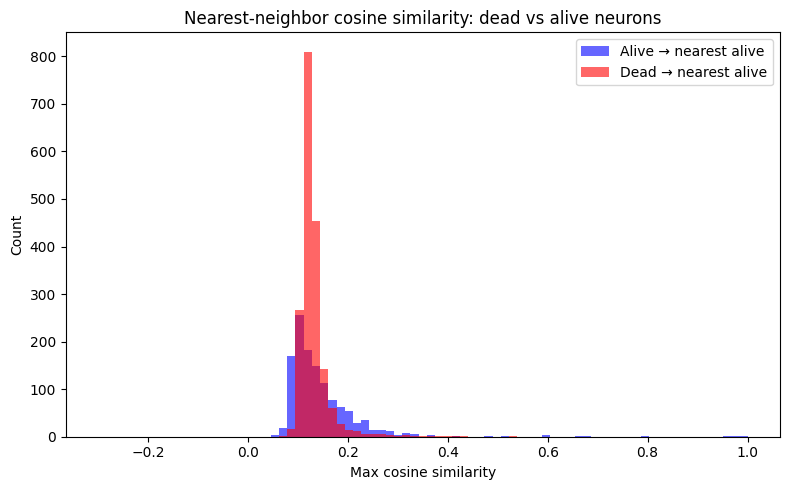

In [17]:
fig, ax = plt.subplots(figsize=(8, 5))
bins = np.linspace(-0.3, 1.0, 80)
ax.hist(nn_alive_vals, bins=bins, alpha=0.6, label='Alive → nearest alive', color='blue')
ax.hist(nn_dead_vals,  bins=bins, alpha=0.6, label='Dead → nearest alive',  color='red')
ax.set_xlabel('Max cosine similarity')
ax.set_ylabel('Count')
ax.set_title('Nearest-neighbor cosine similarity: dead vs alive neurons')
ax.legend()
plt.tight_layout()
plt.show()

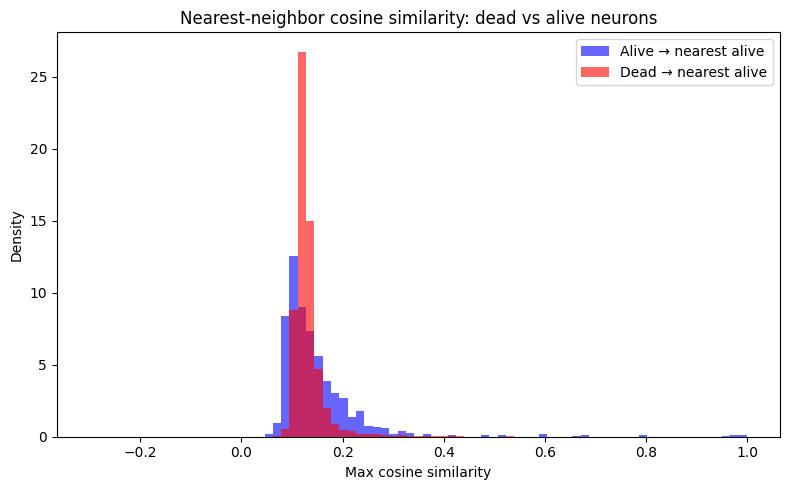

In [18]:
fig, ax = plt.subplots(figsize=(8, 5))
bins = np.linspace(-0.3, 1.0, 80)
ax.hist(nn_alive_vals, bins=bins, alpha=0.6, label='Alive → nearest alive', color='blue', density=True)
ax.hist(nn_dead_vals,  bins=bins, alpha=0.6, label='Dead → nearest alive',  color='red',  density=True)
ax.set_xlabel('Max cosine similarity')
ax.set_ylabel('Density')
ax.set_title('Nearest-neighbor cosine similarity: dead vs alive neurons')
ax.legend()
plt.tight_layout()
plt.show()


In [19]:
duplicate_threshold = 0.8
duplicate_idxs = (cosine_similarities_alive_alive.max(dim=1).values > duplicate_threshold).nonzero().squeeze()
print(f"Alive neurons with a near-duplicate: {len(duplicate_idxs)}")
print(f"Alive neurons with a near-duplicate: {len(duplicate_idxs)} ({100 * len(duplicate_idxs) / len(alive_neuron_idxs):.1f}% of alive)")

Alive neurons with a near-duplicate: 5
Alive neurons with a near-duplicate: 5 (0.4% of alive)


wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.
wandb: Currently logged in as: adityaiyer-m (adityaiyer-m-self) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


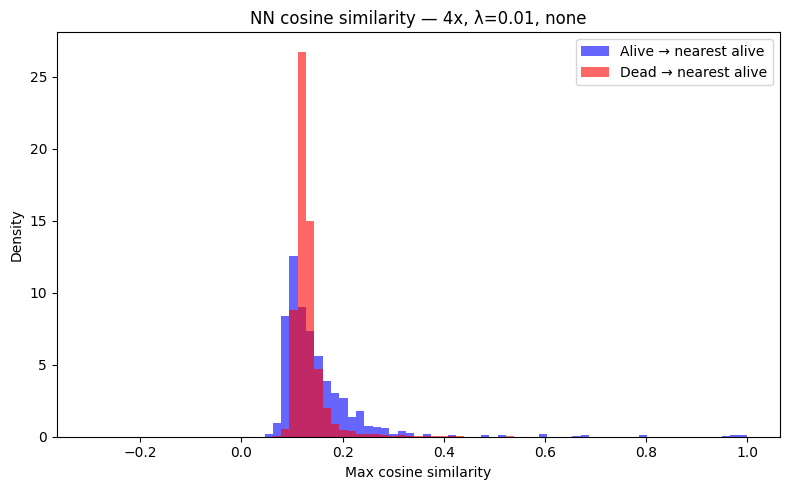

cosine/alive_alive/max,▁
cosine/alive_alive/mean,▁
cosine/alive_alive/median,▁
cosine/alive_alive/std,▁
cosine/dead_alive/max,▁
cosine/dead_alive/mean,▁
cosine/dead_alive/median,▁
cosine/dead_alive/std,▁
dead_neuron/alive_count,▁
dead_neuron/count,▁
+1,...


In [20]:
# --- configure these per run ---
lambda_val        = 0.01   # your L1 coefficient
sampling_strategy = "none"  # e.g. "random", "topk", "neuron_resample"

# --- derived stats ---
total_neurons    = expansion_factor * model_dim
n_dead           = len(dead_neurons_idxs)
n_alive          = len(alive_neuron_idxs)
dead_proportion  = n_dead / total_neurons

dead_alive_stats = {
    "cosine/dead_alive/mean":   float(nn_dead_vals.mean()),
    "cosine/dead_alive/median": float(np.median(nn_dead_vals)),
    "cosine/dead_alive/std":    float(nn_dead_vals.std()),
    "cosine/dead_alive/max":    float(nn_dead_vals.max()),
}
alive_alive_stats = {
    "cosine/alive_alive/mean":   float(nn_alive_vals.mean()),
    "cosine/alive_alive/median": float(np.median(nn_alive_vals)),
    "cosine/alive_alive/std":    float(nn_alive_vals.std()),
    "cosine/alive_alive/max":    float(nn_alive_vals.max()),
}

# --- histogram figure ---
fig_wandb, ax_wandb = plt.subplots(figsize=(8, 5))
bins = np.linspace(-0.3, 1.0, 80)
ax_wandb.hist(nn_alive_vals, bins=bins, alpha=0.6, label='Alive → nearest alive', color='blue', density=True)
ax_wandb.hist(nn_dead_vals,  bins=bins, alpha=0.6, label='Dead → nearest alive',  color='red',  density=True)
ax_wandb.set_xlabel('Max cosine similarity')
ax_wandb.set_ylabel('Density')
ax_wandb.set_title(f'NN cosine similarity — {expansion_factor}x, λ={lambda_val}, {sampling_strategy}')
ax_wandb.legend()
plt.tight_layout()

# --- wandb ---
wandb.init(
    project="sae-for-monosemanticity",
    name=f"dead_neuron_analysis_{expansion_factor}x_{sampling_strategy}_lambda{lambda_val}",
    config={
        "expansion_factor":   expansion_factor,
        "model_dim":          model_dim,
        "lambda":             lambda_val,
        "sampling_strategy":  sampling_strategy,
    }
)

wandb.log({
    "dead_neuron/count":       n_dead,
    "dead_neuron/proportion":  dead_proportion,
    "dead_neuron/alive_count": n_alive,
    **dead_alive_stats,
    **alive_alive_stats,
    "cosine/histogram":        wandb.Image(fig_wandb),
    "cosine/dead_alive_dist":  wandb.Histogram(nn_dead_vals),
    "cosine/alive_alive_dist": wandb.Histogram(nn_alive_vals),
})

plt.show()
wandb.finish()